##  **Loan Applicant Segmentation using KMeans Clustering**

### Project Overview
This notebook explores a loan risk dataset and applies **KMeans clustering** to group loan applicants into different segments based on their numerical characteristics.

### Objectives
- explore and understand the structure of the dataset,
- check for missing values, duplicates, and invalid records,
- prepare the data for clustering,
- apply KMeans clustering to identify groups of similar applicants,
- visualise and interpret the resulting clusters.




In [93]:

# Library imports
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("ready to load data")

ready to load data


### Import the libraries:

- data handling with pandas
- scaling numeric variables
- visualisation with matplotlib
- clustering using KMeans
- cluster evaluation using silhouette score

In [4]:
# Loading the data
data = pd.read_csv("../CSV data/loan_risk_prediction_dataset.csv")
print("data loaded successfully")

data loaded successfully


### Dataset loaded  

The file loaded successfully.

In [92]:
# head of the data
data.head(10)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
5,25,47886.0,18106.0,835.0,13,Male,Masters,New York,Salaried,1
6,38,54748.0,25374.0,760.0,9,Female,High School,New York,Self-Employed,1
7,56,NaN,6279.0,599.0,22,Male,PhD,New York,Unemployed,0
8,36,25918.0,25041.0,777.0,29,Female,Bachelors,San Francisco,Unemployed,0
9,40,43415.0,2065.0,382.0,30,Female,High School,San Francisco,Self-Employed,0


### Preview the data

In [6]:
# quality check
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


### Data quality check

What I found:

- 5000 rows
- 10 columns

**missing values in:**
- Income → 4804 non-null
- CreditScore → 4806 non-null
- Education → 4802 non-null

Dataset is not fully clean.

Data types:

- numeric: Age, Income, LoanAmount, CreditScore, YearsExperience, LoanApproved
- categorical: Gender, Education, City, EmploymentType

In [7]:
# Duplicates check
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

### Duplicates check

(0) Duplications detected

In [8]:
# Check for duplicate records in dataset
data.duplicated().sum()

np.int64(0)

In [9]:
# Statystical overview
data.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


### Statistics analysis

- Age ranges from 18 to 69
- Income has suspicious values, including a minimum of -3731 - **negative value**
- LoanAmount also has suspicious values, including a minimum of -10059 - **negative value**
- CreditScore ranges from 300 to 849
- YearsExperience ranges from 0 to 39
- LoanApproved is binary and has mean around 0.23 - **23% of applicants were approved**

In [59]:
# factors for clustering

features = ["Age", "Income", "LoanAmount", "CreditScore", "YearsExperience"]

In [60]:
cluster_data = data[features].copy()

In [61]:
# remove missing values
cluster_data = cluster_data.dropna()

In [62]:
# quality check
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [63]:
# remove impossible negative values

cluster_data = cluster_data[(cluster_data["Income"] >= 0) & (cluster_data["LoanAmount"] >= 0) ]

In [64]:
cluster_data.head(7)

,Age,Income,LoanAmount,CreditScore,YearsExperience
0,56,48353.0,31258.0,675.0,20
1,69,57462.0,23262.0,586.0,6
2,46,44219.0,26530.0,781.0,26
3,32,56307.0,11531.0,549.0,11
4,60,37034.0,27871.0,500.0,19
5,25,47886.0,18106.0,835.0,13
6,38,54748.0,25374.0,760.0,9


In [65]:
scaler = MinMaxScaler()
X = scaler.fit(cluster_data).transform(cluster_data)
X = pd.DataFrame(X)
X.columns = cluster_data.columns

In [66]:
# KMeans Clustering started here
x = data
kMeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y = kMeans.fit_predict(X)
print(y)


[2 2 0 ... 1 0 2]


In [67]:
cluster_data.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience
0,56,48353.0,31258.0,675.0,20
1,69,57462.0,23262.0,586.0,6
2,46,44219.0,26530.0,781.0,26
3,32,56307.0,11531.0,549.0,11
4,60,37034.0,27871.0,500.0,19


In [68]:
# KMeans Clustering for k=5
x = data
kMeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y = kMeans.fit_predict(X)
print(y)

[2 2 2 ... 4 2 1]


In [69]:
cluster_data["Cluster"] = y

In [70]:
# Extract Group "0" claster
cluster_data[cluster_data["Cluster"] == 0]

,Age,Income,LoanAmount,CreditScore,YearsExperience,Cluster
4,60,37034.0,27871.0,500.0,19,0
9,40,43415.0,2065.0,382.0,30,0
22,55,75575.0,8608.0,561.0,28,0
28,61,28994.0,29296.0,361.0,30,0
30,66,71255.0,19346.0,353.0,28,0
...,...,...,...,...,...,...
4969,58,33347.0,23108.0,354.0,27,0
4970,53,58938.0,13558.0,452.0,23,0
4972,46,44947.0,12481.0,585.0,35,0
4982,65,55617.0,27168.0,477.0,28,0


In [71]:
# Extract Group "3" claster
cluster_data[cluster_data["Cluster"] == 2]

,Age,Income,LoanAmount,CreditScore,YearsExperience,Cluster
0,56,48353.0,31258.0,675.0,20,2
1,69,57462.0,23262.0,586.0,6,2
2,46,44219.0,26530.0,781.0,26,2
32,59,52315.0,21273.0,823.0,8,2
36,64,52307.0,26458.0,735.0,24,2
...,...,...,...,...,...,...
4966,49,30826.0,29351.0,649.0,22,2
4981,68,52185.0,17476.0,759.0,11,2
4990,45,53173.0,16452.0,614.0,24,2
4992,66,45575.0,32748.0,803.0,39,2


In [72]:
# Groups check

cluster_data["Cluster"].value_counts()

Cluster
3    1021
2     990
4     989
1     808
0     784
Name: count, dtype: int64

In [73]:
# Statystical summarisation for claster 3
cluster_data[ cluster_data["Cluster"] == 3].describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Cluster
count,1021.000000,1021.000000,1021.000000,1021.000000,1021.000000,1021.0
mean,29.158668,49052.377081,19992.919687,582.553379,29.761998,3.0
std,7.500608,14906.224673,7870.353214,143.611159,6.149220,0.0
min,18.000000,6735.000000,45.000000,301.000000,15.000000,3.0
25%,23.000000,39070.000000,14285.000000,468.000000,25.000000,3.0
50%,28.000000,48956.000000,19982.000000,587.000000,30.000000,3.0
75%,35.000000,59369.000000,25347.000000,691.000000,35.000000,3.0
max,48.000000,95929.000000,47185.000000,849.000000,39.000000,3.0


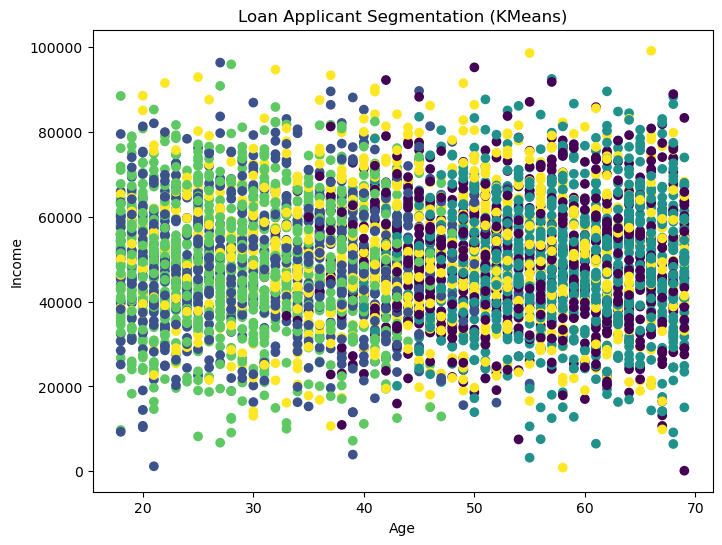

In [74]:
# KMeans Cluster Visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    x=cluster_data["Age"],
    y=cluster_data["Income"],
    c=cluster_data["Cluster"]
)

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Loan Applicant Segmentation (KMeans)")
plt.show()

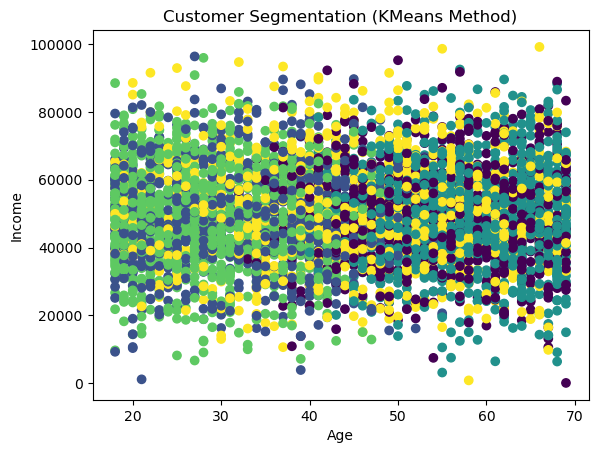

In [75]:
# KMeans Cluster
data_plot = cluster_data.copy()

plt.scatter(
    x=data_plot["Age"],
    y=data_plot["Income"],
    c=data_plot["Cluster"]
)

# Visualisation 

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Customer Segmentation (KMeans Method)")
plt.show()

In [76]:
cluster_data[cluster_data["Cluster"] == 2].describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Cluster
count,990.000000,990.000000,990.000000,990.000000,990.000000,990.0
mean,57.584848,49335.610101,20104.438384,722.105051,20.478788,2.0
std,7.505332,14894.143106,7724.491037,80.222801,9.907308,0.0
min,37.000000,3192.000000,4.000000,511.000000,0.000000,2.0
25%,52.000000,39885.250000,14955.750000,659.000000,13.000000,2.0
50%,58.000000,48830.500000,19869.500000,727.000000,21.000000,2.0
75%,64.000000,59263.750000,25477.750000,791.000000,28.000000,2.0
max,69.000000,92502.000000,48353.000000,849.000000,39.000000,2.0


In [77]:
# Importing the necessary libraries for SimpleImputer and StandardScaler        
from sklearn.impute import SimpleImputer    
from sklearn.preprocessing import StandardScaler

In [84]:
# Fill missing values

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

In [85]:
# Scale features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [86]:
# KMeans Clustering started here

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [87]:
# Fit model

cluster_data = pd.DataFrame(X_imputed, columns =features)
cluster_data["Cluster"] = clusters

In [ ]:
# Head of the cluster data
cluster_data.head() 

,Age,Income,LoanAmount,CreditScore,YearsExperience,Cluster
0,0.745098,0.487027,0.646425,0.683060,0.512821,0
1,1.000000,0.579022,0.481044,0.520947,0.153846,0
2,0.549020,0.445277,0.548636,0.876138,0.666667,2
3,0.274510,0.567357,0.238412,0.453552,0.282051,0
4,0.823529,0.372714,0.576372,0.364299,0.487179,1


In [ ]:
# Count of values in each cluster
cluster_data["Cluster"].value_counts()  

Cluster
1    1721
2    1440
0    1431
Name: count, dtype: int64

In [90]:
# silhouette score for KMeans clustering

score = silhouette_score(X_scaled, clusters)
print("Silhouette score:", round(score, 3))

Silhouette score: 0.139


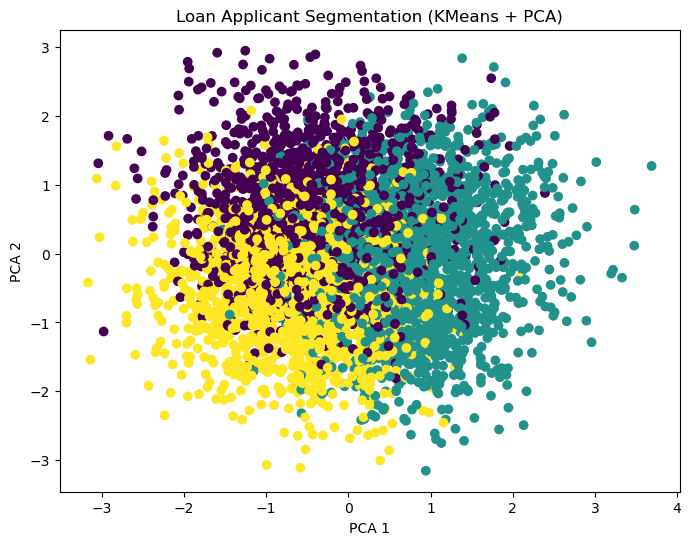

In [91]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Loan Applicant Segmentation (KMeans + PCA)")
plt.show()